
## Étape 0 : Imports et Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.pipeline import Pipeline

# Classification
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression

# Metriques
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)


# Optuna
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
    print("Optuna disponible")
except ImportError:
    OPTUNA_AVAILABLE = False
    print("Optuna non installe -- pip install optuna")

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
PALETTE = 'viridis'
print('\nImports reussis.')

Optuna non installe -- pip install optuna

Imports reussis.



## Régression — Prédiction de `Prix_Revente`


In [31]:
reg_target = 'Prix_Revente'
reg_features = [c for c in df_clean.columns if c not in [reg_target, 'Rapport_Collecte']]

X_reg = df_clean[reg_features]
y_reg = df_clean[reg_target]

print(f"Features régression : {reg_features}")
print(f"X_reg shape: {X_reg.shape}")

# 1. SPLIT d'abord (sur données BRUTES)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_reg, y_reg, test_size=0.30, random_state=42)
X_v, X_te, y_v, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)

print(f"\nSplit terminé:")
print(f"  Train : {X_tr.shape}")
print(f"  Val   : {X_v.shape}")
print(f"  Test  : {X_te.shape}")

# 2. SCALE ensuite (fit uniquement sur TRAIN)
scaler_reg = StandardScaler()
X_tr_scaled = scaler_reg.fit_transform(X_tr)   # ← fit sur TRAIN seulement
X_v_scaled = scaler_reg.transform(X_v)         # ← transform sur VAL
X_te_scaled = scaler_reg.transform(X_te)       # ← transform sur TEST

print(f"\n Standardisation terminée (fit sur Train uniquement)")
print(f"  Train mean: {X_tr_scaled.mean():.2e}")
print(f"  Test mean:  {X_te_scaled.mean():.2e}")

Features régression : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie', 'Source']
X_reg shape: (2361, 7)

Split terminé:
  Train : (1652, 7)
  Val   : (354, 7)
  Test  : (355, 7)

 Standardisation terminée (fit sur Train uniquement)
  Train mean: -3.69e-18
  Test mean:  2.35e-02


In [32]:
# 3. Fonction d'évaluation (utilise les données scalées)
def eval_reg(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    y_pr = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(yte, y_pr))
    mae = mean_absolute_error(yte, y_pr)
    r2 = r2_score(yte, y_pr)
    cv_r2 = cross_val_score(model, Xtr, ytr, cv=5, scoring='r2').mean()
    print(f"  {name:30s} -> RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  CV-R2={cv_r2:.4f}")
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'CV_R2': cv_r2, 'y_pred': y_pr}

# 4. Entraînement et évaluation (avec données scalées)
print("\n=== Regression -- Evaluation sur Test set ===")
reg_results = {}

reg_results['Linear Regression'] = eval_reg('Linear Regression', LinearRegression(), X_tr_scaled, y_tr, X_te_scaled, y_te)
reg_results['Ridge (alpha=1)'] = eval_reg('Ridge (alpha=1)', Ridge(alpha=1), X_tr_scaled, y_tr, X_te_scaled, y_te)
reg_results['Lasso (alpha=0.1)'] = eval_reg('Lasso (alpha=0.1)', Lasso(alpha=0.1, max_iter=5000), X_tr_scaled, y_tr, X_te_scaled, y_te)
reg_results['Random Forest Reg'] = eval_reg('Random Forest Reg', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_tr_scaled, y_tr, X_te_scaled, y_te)
reg_results['Gradient Boosting Reg'] = eval_reg('Gradient Boosting Reg', GradientBoostingRegressor(n_estimators=100, random_state=42), X_tr_scaled, y_tr, X_te_scaled, y_te)
reg_results['kNN Reg'] = eval_reg('kNN Reg', KNeighborsRegressor(n_neighbors=5), X_tr_scaled, y_tr, X_te_scaled, y_te)
reg_results['SVR (RBF)'] = eval_reg('SVR (RBF)', SVR(kernel='rbf'), X_tr_scaled, y_tr, X_te_scaled, y_te)


=== Regression -- Evaluation sur Test set ===
  Linear Regression              -> RMSE=1.6989  MAE=1.1081  R2=0.8605  CV-R2=0.8925
  Ridge (alpha=1)                -> RMSE=1.7003  MAE=1.1099  R2=0.8603  CV-R2=0.8925
  Lasso (alpha=0.1)              -> RMSE=1.8880  MAE=1.3043  R2=0.8277  CV-R2=0.8728
  Random Forest Reg              -> RMSE=1.3200  MAE=0.3586  R2=0.9158  CV-R2=0.9682
  Gradient Boosting Reg          -> RMSE=1.3058  MAE=0.4229  R2=0.9176  CV-R2=0.9666
  kNN Reg                        -> RMSE=1.3501  MAE=0.5239  R2=0.9119  CV-R2=0.9493
  SVR (RBF)                      -> RMSE=1.2781  MAE=0.5114  R2=0.9210  CV-R2=0.9523


In [33]:
# 5. Tableau comparatif
results_reg = pd.DataFrame(
    {k: {m: v for m, v in r.items() if m != 'y_pred'} for k, r in reg_results.items()}
).T.round(4).sort_values('R2', ascending=False)

display(results_reg.style.highlight_max(subset=['R2', 'CV_R2'], color='lightgreen')
                          .highlight_min(subset=['RMSE', 'MAE'], color='lightgreen'))


,RMSE,MAE,R2,CV_R2
SVR (RBF),1.278100,0.511400,0.921000,0.952300
Gradient Boosting Reg,1.305800,0.422900,0.917600,0.966600
Random Forest Reg,1.320000,0.358600,0.915800,0.968200
kNN Reg,1.350100,0.523900,0.911900,0.949300
Linear Regression,1.698900,1.108100,0.860500,0.892500
Ridge (alpha=1),1.700300,1.109900,0.860300,0.892500
Lasso (alpha=0.1),1.888000,1.304300,0.827700,0.872800


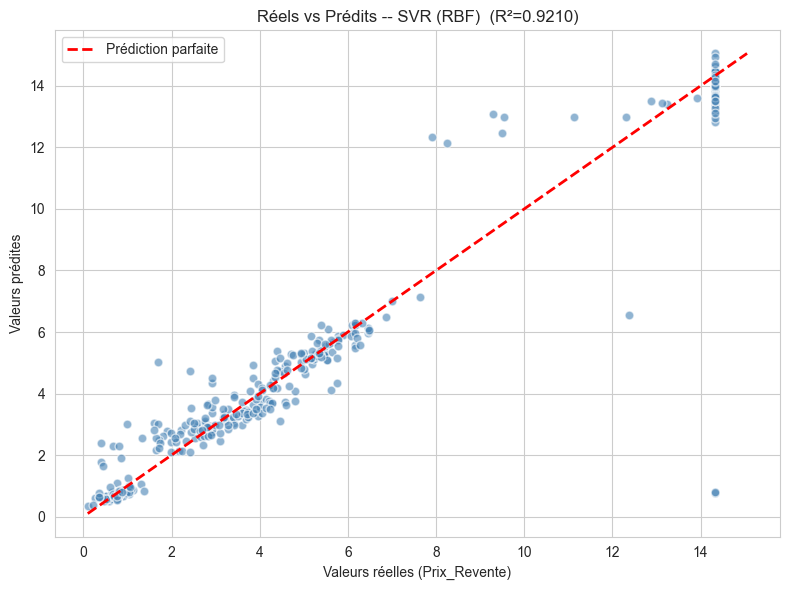

In [34]:
# ========== GRAPHIQUE RÉELS VS PRÉDITS (RÉGRESSION) ==========
best_reg_name = results_reg['R2'].idxmax()
y_pred_best = reg_results[best_reg_name]['y_pred']

plt.figure(figsize=(8, 6))
plt.scatter(y_te, y_pred_best, alpha=0.6, color='steelblue', edgecolors='white', s=40)
mn, mx = min(y_te.min(), y_pred_best.min()), max(y_te.max(), y_pred_best.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Prédiction parfaite')
plt.xlabel('Valeurs réelles (Prix_Revente)')
plt.ylabel('Valeurs prédites')
plt.title(f'Réels vs Prédits -- {best_reg_name}  (R²={results_reg.loc[best_reg_name, "R2"]:.4f})')
plt.legend()
plt.tight_layout()
plt.show()


## Partie 5 : Tuning des Hyperparamètres

### 5.1 — GridSearchCV (exhaustif)

In [35]:
# ========== GRIDSEARCHCV POUR GRADIENT BOOSTING ==========
print("\n=== GridSearchCV pour Gradient Boosting ===")

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.10, 0.20],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

# ← CORRIGÉ : utiliser X_train_scaled au lieu de X_train
grid_search.fit(X_train_scaled, y_train)

best_gbc_grid = grid_search.best_estimator_
y_pred_grid = best_gbc_grid.predict(X_test_scaled)  
grid_f1 = f1_score(y_test, y_pred_grid, average='weighted', zero_division=0)
grid_acc = accuracy_score(y_test, y_pred_grid)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"CV F1 (val)          = {grid_search.best_score_:.4f}")
print(f"Test F1              = {grid_f1:.4f}")
print(f"Test Accuracy        = {grid_acc:.4f}")


=== GridSearchCV pour Gradient Boosting ===
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
CV F1 (val)          = 0.9927
Test F1              = 0.9944
Test Accuracy        = 0.9944


### 5.2 — Optuna (Bayesian Optimization / TPE)

> **Optuna** utilise le TPE (Tree-structured Parzen Estimator) pour explorer intelligemment  
> l'espace des hyperparamètres, bien plus efficace que la grille exhaustive pour les grands espaces.

In [36]:
# ========== OPTUNA POUR GRADIENT BOOSTING ==========
print("\n=== Optimisation Optuna pour Gradient Boosting ===")

if OPTUNA_AVAILABLE:
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 6),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }
        clf = GradientBoostingClassifier(**params, random_state=42)
        cv_s = cross_val_score(
            clf, 
            X_train_scaled,  # ← CORRIGÉ : utiliser X_train_scaled
            y_train,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='f1_weighted',
            n_jobs=-1
        )
        return cv_s.mean()

    study = optuna.create_study(direction='maximize', study_name='GBC_Optuna')
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    best_gbc_optuna = GradientBoostingClassifier(**study.best_params, random_state=42)
    best_gbc_optuna.fit(X_train_scaled, y_train)  
    y_pred_optuna = best_gbc_optuna.predict(X_test_scaled) 
    
    optuna_f1 = f1_score(y_test, y_pred_optuna, average='weighted', zero_division=0)
    optuna_acc = accuracy_score(y_test, y_pred_optuna)

    print(f"\nBest trial    : {study.best_trial.number}")
    print(f"Best CV F1    = {study.best_value:.4f}")
    print(f"Best params   = {study.best_params}")
    print(f"Test F1       = {optuna_f1:.4f}")
    print(f"Test Accuracy = {optuna_acc:.4f}")

    # Courbe de convergence
    trials_df = study.trials_dataframe()
    plt.figure(figsize=(10, 4))
    plt.plot(trials_df['number'], trials_df['value'], alpha=0.4, label='Trial F1', color='steelblue')
    plt.plot(trials_df['number'], trials_df['value'].cummax(),
             color='red', linewidth=2, label='Meilleur F1 cumulé')
    plt.xlabel('Numéro du trial')
    plt.ylabel('F1 (CV)')
    plt.title("Convergence de l'optimisation Optuna")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Optuna non installé (pip install optuna).")
    optuna_f1 = None
    optuna_acc = None


=== Optimisation Optuna pour Gradient Boosting ===
Optuna non installé (pip install optuna).


### 5.3 — Comparaison : Baseline vs GridSearch vs Optuna


=== Comparaison des stratégies de tuning GBC ===


,F1-Test,Accuracy
Modèle,,
GBC Baseline,0.994400,0.994400
GBC + GridSearchCV,0.994400,0.994400


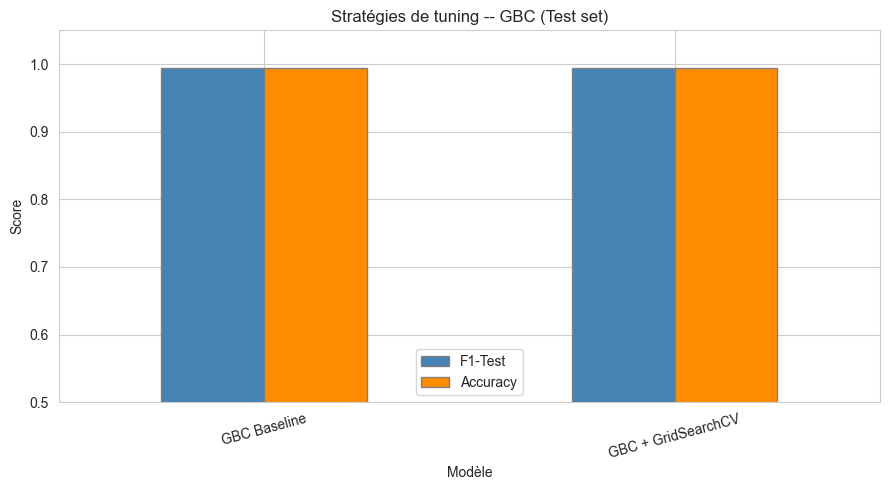

In [37]:
# ========== COMPARAISON DES STRATÉGIES DE TUNING ==========
print("\n=== Comparaison des stratégies de tuning GBC ===")

rows = [
    {'Modèle': 'GBC Baseline', 'F1-Test': gbc_f1, 'Accuracy': gbc_acc},
    {'Modèle': 'GBC + GridSearchCV', 'F1-Test': grid_f1, 'Accuracy': grid_acc},
]
if optuna_f1 is not None:
    rows.append({'Modèle': 'GBC + Optuna', 'F1-Test': optuna_f1, 'Accuracy': optuna_acc})

comparison_df = pd.DataFrame(rows).set_index('Modèle').round(4)
display(comparison_df.style.highlight_max(axis=0, color='lightgreen'))

# Graphique
comparison_df.plot(kind='bar', figsize=(9, 5), color=['steelblue', 'darkorange'], edgecolor='grey')
plt.title('Stratégies de tuning -- GBC (Test set)')
plt.xticks(rotation=15)
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.tight_layout()
plt.show()